In [1]:
import numpy as np
import matplotlib.pyplot as plt

class discrete_MDP:
    def __init__(self, states, actions, transition_probabilities, discount_factor, rewards):
        self.states = states
        self.actions = actions
        self.transition_probabilities = transition_probabilities
        self.discount_factor = discount_factor
        self.rewards = rewards
        
class discrete_RL:
    def __init__(self, mdp):
        self.mdp = mdp
        self.value_function = np.zeros(len(mdp.states))
        self.policy = np.zeros(len(mdp.states), dtype=int)
    
    def value_iteration(self, epsilon=1e-6):
        while True:
            delta = 0
            for s in range(len(self.mdp.states)):
                v = self.value_function[s]
                action_values = np.zeros(len(self.mdp.actions))
                for a in range(len(self.mdp.actions)):
                    for s_prime in range(len(self.mdp.states)):
                        action_values[a] += self.mdp.transition_probabilities[s, a, s_prime] * (self.mdp.rewards[s, a, s_prime] + self.mdp.discount_factor * self.value_function[s_prime])
                self.value_function[s] = np.max(action_values)
                self.policy[s] = np.argmax(action_values)
                delta = max(delta, abs(v - self.value_function[s]))
            if delta < epsilon:
                break
        
    def policy_iteration(self):
        while True:
            # Policy Evaluation
            while True:
                delta = 0
                for s in range(len(self.mdp.states)):
                    v = self.value_function[s]
                    a = self.policy[s]
                    self.value_function[s] = sum(self.mdp.transition_probabilities[s, a, s_prime] * (self.mdp.rewards[s, a, s_prime] + self.mdp.discount_factor * self.value_function[s_prime]) for s_prime in range(len(self.mdp.states)))
                    delta = max(delta, abs(v - self.value_function[s]))
                if delta < 1e-6:
                    break
            
            # Policy Improvement
            policy_stable = True
            for s in range(len(self.mdp.states)):
                old_action = self.policy[s]
                action_values = np.zeros(len(self.mdp.actions))
                for a in range(len(self.mdp.actions)):
                    action_values[a] = sum(self.mdp.transition_probabilities[s, a, s_prime] * (self.mdp.rewards[s, a, s_prime] + self.mdp.discount_factor * self.value_function[s_prime]) for s_prime in range(len(self.mdp.states)))
                self.policy[s] = np.argmax(action_values)
                if old_action != self.policy[s]:
                    policy_stable = False
            
            if policy_stable:
                break

In [2]:
mdp = discrete_MDP(states=[0, 1, 2], actions=[0, 1],
                   transition_probabilities=np.array([[[0.8, 0.2, 0.0], [0.1, 0.9, 0.0]], [[0.7, 0.3, 0.0], [0.2, 0.8, 0.0]], [[0.6, 0.4, 0.0], [0.3, 0.7, 0.0]]]),
                   discount_factor=0.9, rewards=np.array([[[5, -1, 0], [-1, 5, 0]], [[5, -1, 0], [-1, 5, 0]], [[5, -1, 0], [-1, 5, 0]]]))

rl = discrete_RL(mdp)
rl.value_iteration()
print("Optimal Value Function:", rl.value_function)
print("Optimal Policy:", rl.policy)

Optimal Value Function: [39.54127722 38.99081866 38.44036061]
Optimal Policy: [1 1 1]


In [11]:
maze = np.array([
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 1],
    [1, 1, 1, 0, 1, 0, 1, 1, 0, 1],
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 0, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 1, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 1, 0, 1, 0, 0, 1],
    [1, 1, 1, 0, 1, 1, 1, 1, 0, 0]
])

start = (0, 0)
goal = (9, 9)

rows, cols = maze.shape
n_states = rows * cols

# Actions: up, down, left, right
ACTIONS = {
    0: (-1, 0),  # up
    1: (1, 0),   # down
    2: (0, -1),  # left
    3: (0, 1)    # right
}
n_actions = len(ACTIONS)

def state_to_idx(i, j):
    return i * cols + j

def idx_to_state(s):
    return divmod(s, cols)

P = np.zeros((n_states, n_actions, n_states))
R = np.zeros((n_states, n_actions, n_states))

goal_idx = state_to_idx(*goal)

for i in range(rows):
    for j in range(cols):
        s = state_to_idx(i, j)

        # Skip walls completely
        if maze[i, j] == 1:
            continue

        for a, (di, dj) in ACTIONS.items():

            # Terminal state: self-loop
            if s == goal_idx:
                P[s, a, s] = 1.0
                R[s, a, s] = 0.0
                continue

            ni, nj = i + di, j + dj

            # Invalid move → stay in place
            if (
                ni < 0 or ni >= rows or
                nj < 0 or nj >= cols or
                maze[ni, nj] == 1
            ):
                ns = s
            else:
                ns = state_to_idx(ni, nj)

            P[s, a, ns] = 1.0

            # Rewards
            if ns == goal_idx:
                R[s, a, ns] = 100.0
            else:
                R[s, a, ns] = -1.0  # step cost

mdp_maze = discrete_MDP(
    states=list(range(n_states)),
    actions=list(range(n_actions)),
    transition_probabilities=P,
    rewards=R,
    discount_factor=0.9
)

rl_maze = discrete_RL(mdp_maze)
# rl_maze.value_iteration()
# print("Optimal Value Function for Maze:", rl_maze.value_function)
# print("Optimal Policy for Maze:", rl_maze.policy)
rl_maze.policy_iteration()
print("Optimal Value Function after Policy Iteration:", rl_maze.value_function)
print("Optimal Policy after Policy Iteration:", rl_maze.policy)


Optimal Value Function after Policy Iteration: [ -0.25076807   0.           0.           0.           0.
   0.           0.           0.           0.           0.
   0.83247992   2.0360888    3.373432     4.85936889   0.
  17.96052411  21.06724901  24.51916557  28.35462841   0.
   0.           0.           0.           6.51040988   0.
  15.1644717    0.           0.          32.61625379   0.
   0.           4.85936889   6.51040988   8.34489987  10.38322208
  12.64802453   0.          42.612659    37.3513931    0.
   0.           3.373432     0.           0.           0.
   0.           0.          48.45851      0.           0.
   0.           2.0360888    0.          32.61625379  37.3513931
  42.612659    48.45851     54.9539       0.           0.
   0.           0.83247992   0.          28.35462841   0.
   0.           0.          62.171        0.           0.
   0.          -0.25076807   0.          24.51916557   0.
  54.9539      62.171       70.19         0.           0.
   0.     

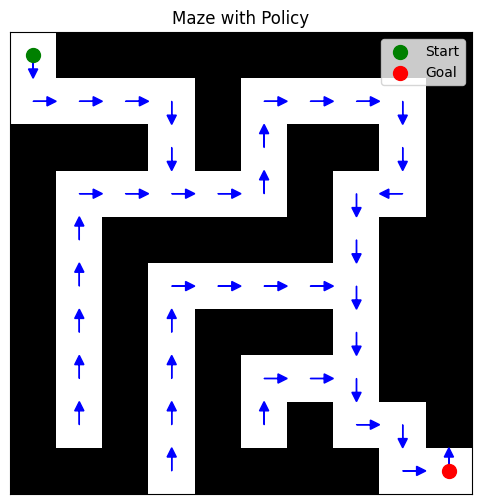

In [12]:
def draw_maze_with_policy(maze, policy, start, goal):
    fig, ax = plt.subplots(figsize=(6, 6))

    # Draw maze
    ax.imshow(maze, cmap="gray_r")

    for i in range(rows):
        for j in range(cols):
            if maze[i, j] == 0:
                s = state_to_idx(i, j)
                a = policy[s]
                di, dj = ACTIONS[a]
                ax.arrow(
                    j, i,
                    0.3 * dj, 0.3 * di,
                    head_width=0.2,
                    head_length=0.2,
                    fc="blue",
                    ec="blue"
                )

    # Start & goal
    ax.scatter(start[1], start[0], c="green", s=100, label="Start")
    ax.scatter(goal[1], goal[0], c="red", s=100, label="Goal")

    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend()
    ax.set_title("Maze with Policy")
    plt.show()

draw_maze_with_policy(maze, rl_maze.policy, start, goal)
